# Import thư viện và thiết lập chung

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import normaltest, spearmanr
import missingno as msno

# =============================================================================
# GLOBAL STYLE: white background for all plots
# =============================================================================
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "axes.edgecolor": "#cccccc",
    "axes.grid": True,
    "grid.color": "#eeeeee",
    "grid.linestyle": "--",
    "font.size": 11,
})
PALETTE = "Set2"

# Tải và làm sạch dữ liệu ban đầu

In [2]:
# =============================================================================
# 0. LOAD DATA
# =============================================================================

print("=" * 70)
print("LOADING DATASET")
print("=" * 70)

df = pd.read_csv("../data/raw/adult.csv")

# Standardize column names: replace '.' with '_' and strip whitespace
df.columns = df.columns.str.strip().str.replace(".", "_", regex=False)

# Replace '?' string (used to encode missing values in this dataset) with NaN
df.replace("?", np.nan, inplace=True)
df.replace(" ?", np.nan, inplace=True)

# Strip leading/trailing whitespace from string columns
str_cols = df.select_dtypes(include="object").columns
df[str_cols] = df[str_cols].apply(lambda col: col.str.strip())

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("\nFirst 5 rows:")
print(df.head())

LOADING DATASET
Shape: 32,561 rows × 15 columns

First 5 rows:
   age workclass  fnlwgt     education  education_num marital_status  \
0   90       NaN   77053       HS-grad              9        Widowed   
1   82   Private  132870       HS-grad              9        Widowed   
2   66       NaN  186061  Some-college             10        Widowed   
3   54   Private  140359       7th-8th              4       Divorced   
4   41   Private  264663  Some-college             10      Separated   

          occupation   relationship   race     sex  capital_gain  \
0                NaN  Not-in-family  White  Female             0   
1    Exec-managerial  Not-in-family  White  Female             0   
2                NaN      Unmarried  Black  Female             0   
3  Machine-op-inspct      Unmarried  White  Female             0   
4     Prof-specialty      Own-child  White  Female             0   

   capital_loss  hours_per_week native_country income  
0          4356              40  United

### 📌 Nhận xét: Quá trình Tải & Làm sạch dữ liệu ban đầu

- **Kích thước dữ liệu:** Tập dữ liệu bao gồm **32,561 dòng** và **15 cột**, đây là một kích thước tương đối tốt để thực hiện các phương pháp học máy.
- **Biến mục tiêu (Target Variable):** Cột `income` (thu nhập) phân loại thành `<=50K` và `>50K`.
- **Phát hiện giá trị thiếu sơ bộ:** Các ký tự `?` (thường dùng để đánh dấu dữ liệu thiếu trong tập Adult Census) đã được chuyển đổi thành công sang định dạng `NaN` chuẩn của pandas. Ta có thể thấy rõ điều này ở dòng 0 và 2 tại các cột `workclass` và `occupation`. Việc làm sạch này rất quan trọng để thực hiện phân tích cơ chế thiếu dữ liệu (MCAR/MAR/MNAR) ở các bước tiếp theo.

# 1. BASIC EDA

In [3]:
# --- 1.1 Data Types & Schema ---
print("\n--- 1.1 Data Types ---")
print(df.dtypes)

# Identify numeric vs categorical columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include="object").columns.tolist()
print(f"\nNumeric columns  ({len(num_cols)}): {num_cols}")
print(f"Categorical cols ({len(cat_cols)}): {cat_cols}")

# --- 1.2 Descriptive Statistics ---
print("\n--- 1.2 Descriptive Statistics (Numeric) ---")
print(df[num_cols].describe().round(2))

print("\n--- 1.2 Descriptive Statistics (Categorical) ---")
for col in cat_cols:
    print(f"\n{col} — {df[col].nunique()} unique values:")
    print(df[col].value_counts(dropna=False).head(10))

# --- 1.3 Missing Values Summary ---
print("\n--- 1.3 Missing Values ---")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
missing_df = missing_df[missing_df["Missing Count"] > 0].sort_values("Missing Count", ascending=False)
print(missing_df if not missing_df.empty else "No missing values detected (after '?' replacement).")

# --- 1.4 Duplicate Rows ---
n_dup = df.duplicated().sum()
print(f"\n--- 1.4 Duplicate Rows: {n_dup:,} ({n_dup/len(df)*100:.2f}%) ---")

# --- 1.5 Target Variable Distribution ---
print("\n--- 1.5 Target Distribution (income) ---")
print(df["income"].value_counts(dropna=False))


--- 1.1 Data Types ---
age                int64
workclass         object
fnlwgt             int64
education         object
education_num      int64
marital_status    object
occupation        object
relationship      object
race              object
sex               object
capital_gain       int64
capital_loss       int64
hours_per_week     int64
native_country    object
income            object
dtype: object

Numeric columns  (6): ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
Categorical cols (9): ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country', 'income']

--- 1.2 Descriptive Statistics (Numeric) ---
            age      fnlwgt  education_num  capital_gain  capital_loss  \
count  32561.00    32561.00       32561.00      32561.00      32561.00   
mean      38.58   189778.37          10.08       1077.65         87.30   
std       13.64   105549.98           2.57       7385.29        402.96 

### 📌 Nhận xét: Thống kê mô tả và Khám phá cơ bản (Basic EDA)

- **Cấu trúc & Kiểu dữ liệu:** Tập dữ liệu được phân chia rõ ràng thành 6 biến số (Numeric) và 9 biến phân loại (Categorical).
- **Thống kê biến số:** 
  - `capital_gain` và `capital_loss` có phân phối cực kỳ lệch, với hơn 75% giá trị bằng 0. Khi tiền xử lý có thể cần cân nhắc áp dụng các phép biến đổi (transformation) hoặc gộp nhóm.
  - Tuổi (`age`) dao động từ 17 đến 90, và số giờ làm việc trung bình (`hours_per_week`) là khoảng 40 giờ.
- **Thống kê biến phân loại:** Một số biến có tính mất cân bằng nội tại rất lớn. Ví dụ: `native_country` chủ yếu là United-States (29,170/32,561), `race` đa phần là White.
- **Giá trị thiếu (Missing values):** 
  - Có 3 cột chứa giá trị thiếu: `occupation` (5.66%), `workclass` (5.64%) và `native_country` (1.79%). 
  - *Lưu ý:* Việc có ít nhất một thuộc tính bị thiếu ≥ 5% đã **đáp ứng đúng yêu cầu của Đồ án** đối với tập dữ liệu dạng bảng.
- **Dữ liệu trùng lặp:** Có 24 dòng trùng lặp (0.07%). Tỉ lệ này rất nhỏ và có thể dễ dàng loại bỏ (drop duplicates) mà không ảnh hưởng đến tổng thể.
- **Biến mục tiêu (Target Variable):** Lớp `<=50K` (24,720 mẫu) nhiều gấp khoảng 3.15 lần so với lớp `>50K` (7,841 mẫu). Tập dữ liệu có sự mất cân bằng lớp (class imbalance), có thể cần áp dụng các kỹ thuật resampling (như SMOTE) ở phần nâng cao.

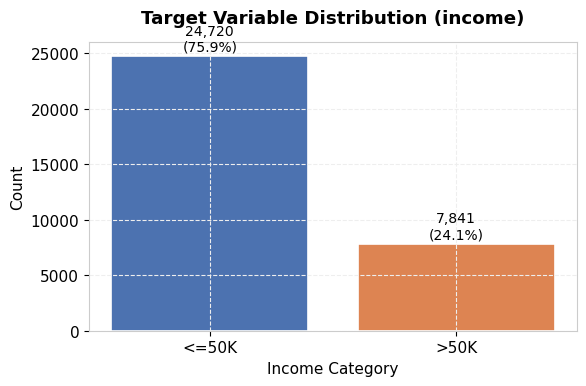

In [4]:
# ── PLOT 1: Target class balance ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
income_counts = df["income"].value_counts()
bars = ax.bar(income_counts.index, income_counts.values,
              color=["#4C72B0", "#DD8452"], edgecolor="white", linewidth=1.2)
for bar, val in zip(bars, income_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            f"{val:,}\n({val/len(df)*100:.1f}%)", ha="center", va="bottom", fontsize=10)
ax.set_title("Target Variable Distribution (income)", fontweight="bold", pad=14)
ax.set_xlabel("Income Category")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

### 📌 Nhận xét: Phân phối Biến mục tiêu (Target Variable)

- Biểu đồ thể hiện rất rõ sự **mất cân bằng lớp (class imbalance)** trong tập dữ liệu.
- Nhóm thu nhập **`<=50K`** chiếm tỷ trọng áp đảo với **24,720 mẫu (75.9%)**.
- Nhóm thu nhập cao **`>50K`** chỉ chiếm **7,841 mẫu (24.1%)**, tức là nhóm thu nhập thấp/trung bình nhiều gấp khoảng 3 lần nhóm thu nhập cao.
- **Tác động đến bài toán:** Sự mất cân bằng này cho thấy nếu sử dụng độ đo Accuracy (độ chính xác) để đánh giá mô hình sau này sẽ không phản ánh đúng hiệu năng thực tế. Chúng ta nên ưu tiên các độ đo như F1-macro, Precision, Recall hoặc AUC-ROC. Đồng thời, ở phần tiền xử lý nâng cao, nhóm cần cân nhắc áp dụng các kỹ thuật cân bằng dữ liệu như SMOTE hay Under-sampling để giúp mô hình học máy hoạt động tốt hơn.

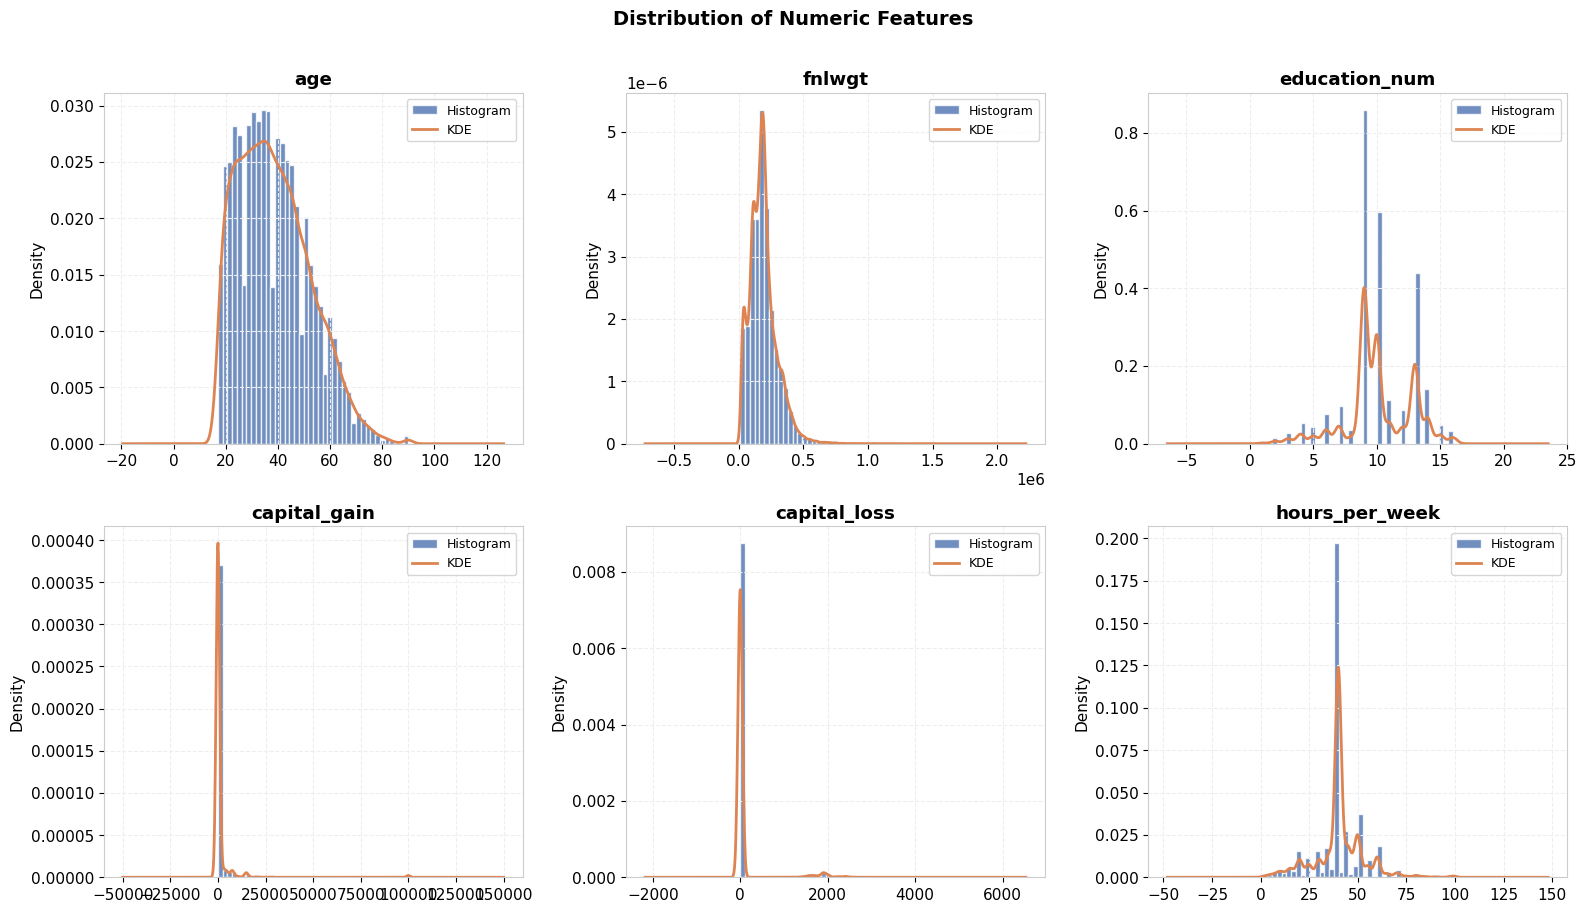

In [5]:
# ── PLOT 2: Numeric feature distributions (histograms + KDE) ─────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    ax = axes[i]
    ax.hist(df[col].dropna(), bins=40, color="#4C72B0", edgecolor="white",
            alpha=0.8, density=True, label="Histogram")
    df[col].dropna().plot.kde(ax=ax, color="#DD8452", linewidth=2, label="KDE")
    ax.set_title(col, fontweight="bold")
    ax.set_xlabel("")
    ax.legend(fontsize=9)
plt.suptitle("Distribution of Numeric Features", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 📌 Nhận xét: Phân phối các biến số (Numeric Features)

Việc quan sát đồ thị Histogram và đường cong mật độ (KDE) cho thấy hầu hết các biến số đều không tuân theo phân phối chuẩn (Normal Distribution):

- **`age` và `fnlwgt`:** Cả hai biến đều có phân phối lệch phải (right-skewed). Đa số các cá nhân trong tập dữ liệu nằm trong độ tuổi thanh niên và trung niên (từ 20 đến 50 tuổi). 
- **`education_num`:** Thể hiện phân phối đa đỉnh (multimodal). Các đỉnh nhọn (spikes) tương ứng với các cột mốc học vấn tiêu chuẩn, trong đó đỉnh cao nhất ở mức 9 (tương đương tốt nghiệp Trung học phổ thông - HS-grad).
- **`capital_gain` và `capital_loss`:** Phân phối cực kỳ lệch và độ thưa rất cao, đại đa số các quan sát đều có giá trị bằng 0. Riêng `capital_gain` xuất hiện một điểm dị thường (outlier) ở mốc giá trị 100,000, có khả năng đây là giá trị trần (cap) được gán chủ đích khi thu thập dữ liệu. Hai biến này có thể cần được biến đổi thành biến phân loại (ví dụ: có/không có thu nhập từ vốn) ở bước tiền xử lý.
- **`hours_per_week`:** Biểu đồ tập trung dày đặc tạo thành một đỉnh cực nhọn tại mốc 40 giờ. Điều này phản ánh rất sát thực tế với chuẩn tuần làm việc toàn thời gian (full-time). 

**💡 Đề xuất cho bước Tiền xử lý:**
Sự lệch chuẩn rõ rệt của các biến số gợi ý rằng việc sử dụng Standard Scaler (Z-score) đơn thuần có thể sẽ không hiệu quả tối ưu. Nhóm nên cân nhắc áp dụng các kỹ thuật như Robust Scaler (để chống chịu ngoại lai) hoặc Quantile Transform để ép dữ liệu về dạng chuẩn hơn, hoặc ưu tiên sử dụng các mô hình học máy dạng cây (Tree-based models) vốn không nhạy cảm với phân phối dữ liệu đầu vào.

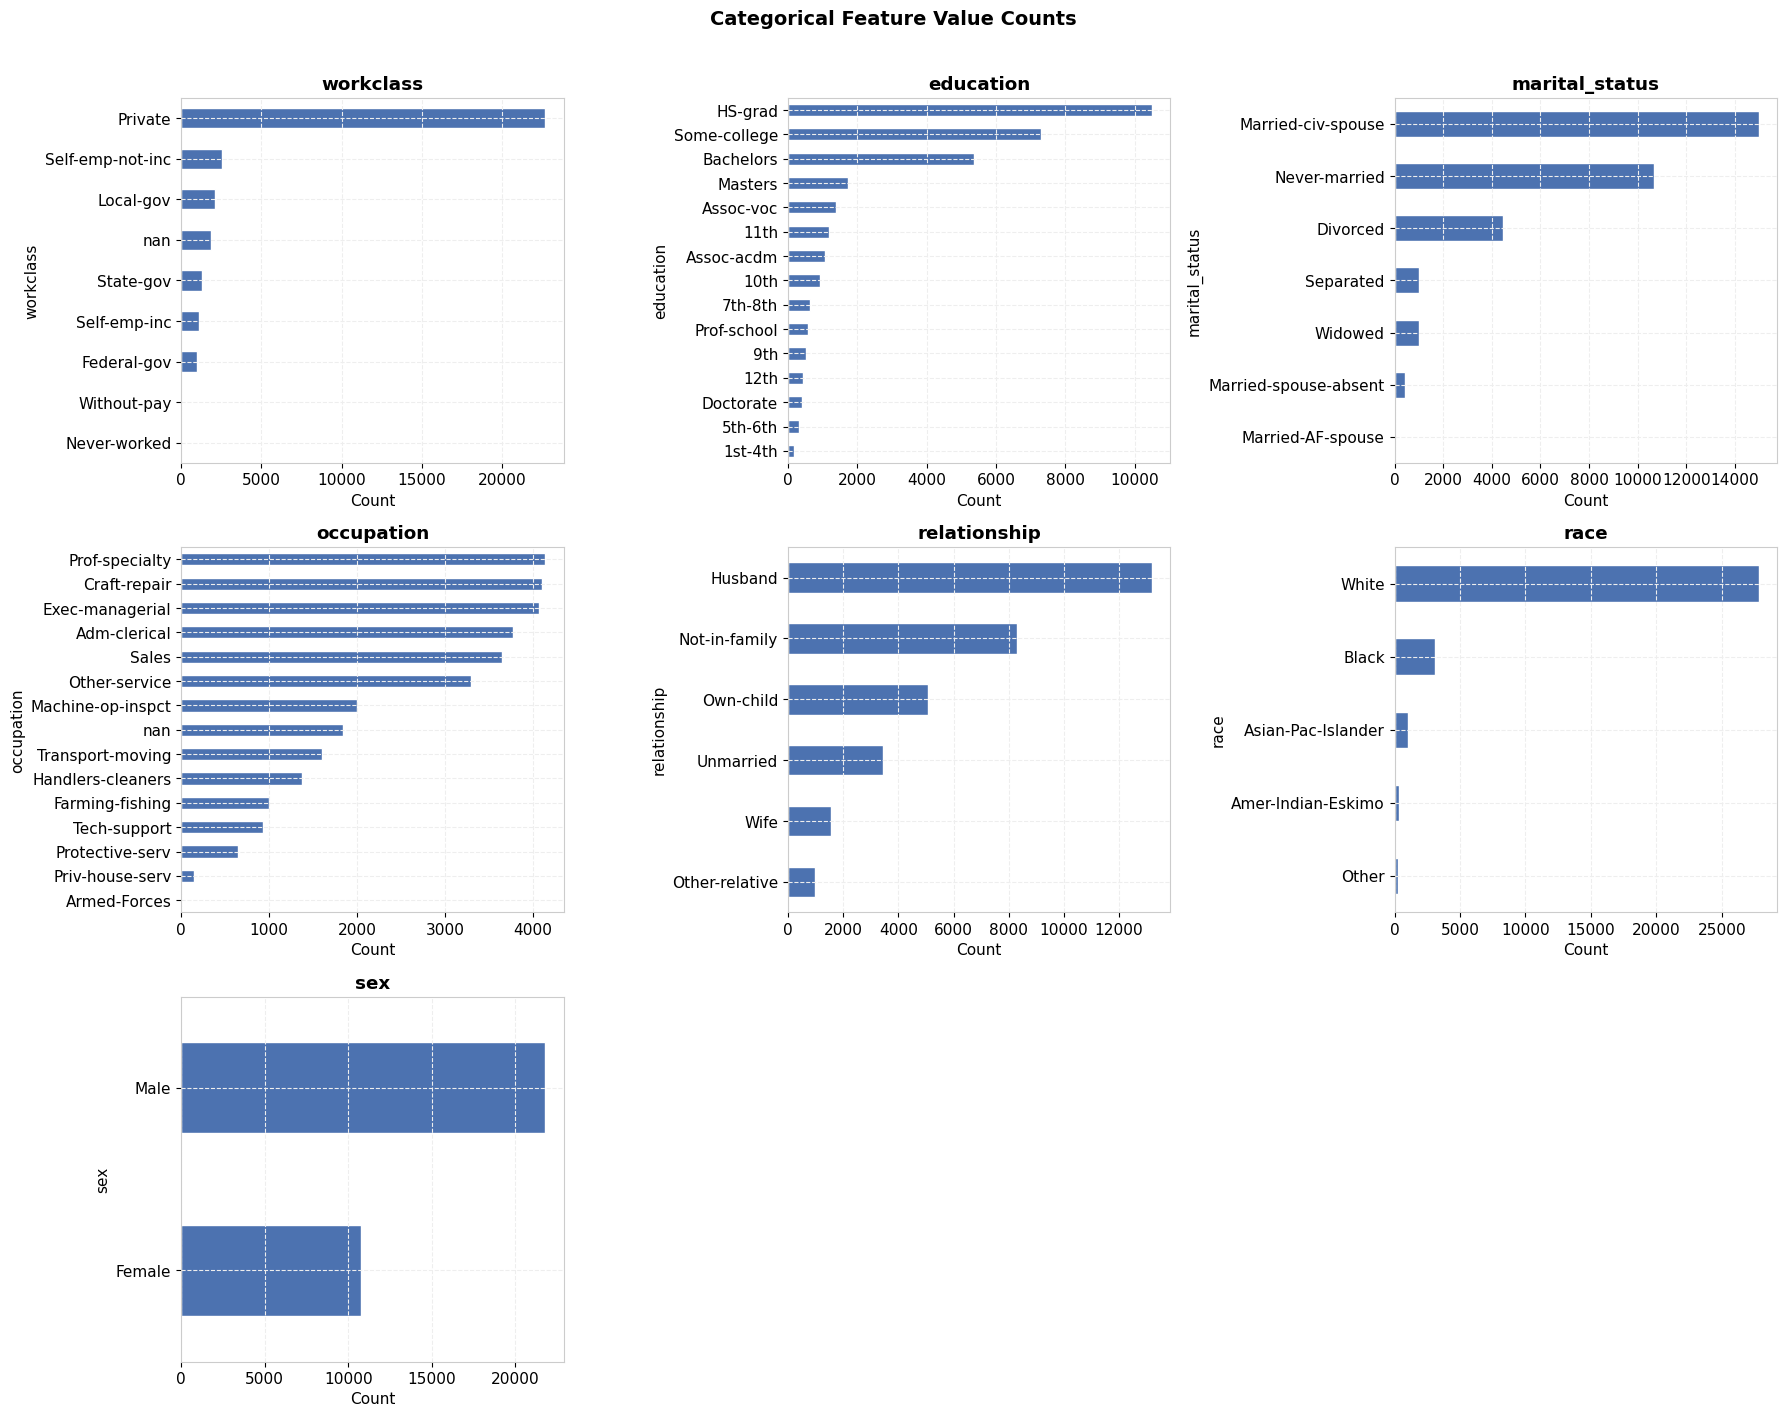

In [6]:
# ── PLOT 3: Categorical feature value counts ──────────────────────────────────
# Exclude 'income' (already plotted) and 'native_country' (too many values — separate)
cat_plot_cols = [c for c in cat_cols if c not in ("income", "native_country")]
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()
for i, col in enumerate(cat_plot_cols):
    ax = axes[i]
    vc = df[col].value_counts(dropna=False).head(15)
    vc.plot(kind="barh", ax=ax, color="#4C72B0", edgecolor="white")
    ax.set_title(col, fontweight="bold")
    ax.set_xlabel("Count")
    ax.invert_yaxis()
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Categorical Feature Value Counts", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 📌 Nhận xét: Phân phối các biến phân loại (Categorical Features)

Biểu đồ đếm số lượng (Count plot) của các biến phân loại cho thấy đặc điểm mất cân bằng cục bộ và sự xuất hiện của các "đuôi dài" (long-tail distributions):

- **Sự thống trị của các giá trị đa số:**
  - **`workclass`**: Khu vực tư nhân (`Private`) chiếm ưu thế tuyệt đối so với các hình thức lao động khác.
  - **`race`**: Nhóm người da trắng (`White`) áp đảo hoàn toàn các chủng tộc khác.
  - **`sex`**: Nam giới (`Male`) có số lượng lớn gần gấp đôi nữ giới (`Female`).
- **Nhiều danh mục hiếm (Rare categories / Long-tail):**
  - **`education`**: Có rất nhiều mức học vấn thấp chiếm tỉ lệ cực nhỏ (vd: `1st-4th`, `5th-6th`, `Preschool`...).
  - **`occupation`**: Nhóm `Armed-Forces` và `Priv-house-serv` có tần suất xuất hiện không đáng kể.
  - **`marital_status`**: Các nhóm như `Married-AF-spouse` hay `Married-spouse-absent` rất ít.
- **Dữ liệu khuyết (Missing Data):** Thanh `nan` xuất hiện rõ rệt ở cả biểu đồ `workclass` và `occupation`, tái khẳng định việc cần thiết phải có chiến lược điền khuyết (Imputation) phù hợp.

**💡 Đề xuất cho bước Tiền xử lý (Preprocessing):**
- **Gộp nhóm (Binning/Grouping):** Nhóm nên cân nhắc gộp các giá trị hiếm thành một nhóm `Other` hoặc gộp theo ngữ nghĩa (ví dụ: gộp các lớp tiểu học/trung học cơ sở trong `education` thành `Low-education`) để giảm số lượng chiều khi mã hóa.
- **Mã hóa (Encoding):** Với các biến có số lượng danh mục vừa phải (như `sex`, `race`), có thể dùng One-Hot Encoding. Với các biến có nhiều danh mục (high-cardinality) như `occupation` hay `education`, nên áp dụng Target Encoding hoặc Frequency Encoding để tránh hiện tượng bùng nổ số chiều (Curse of Dimensionality) và đa cộng tuyến.

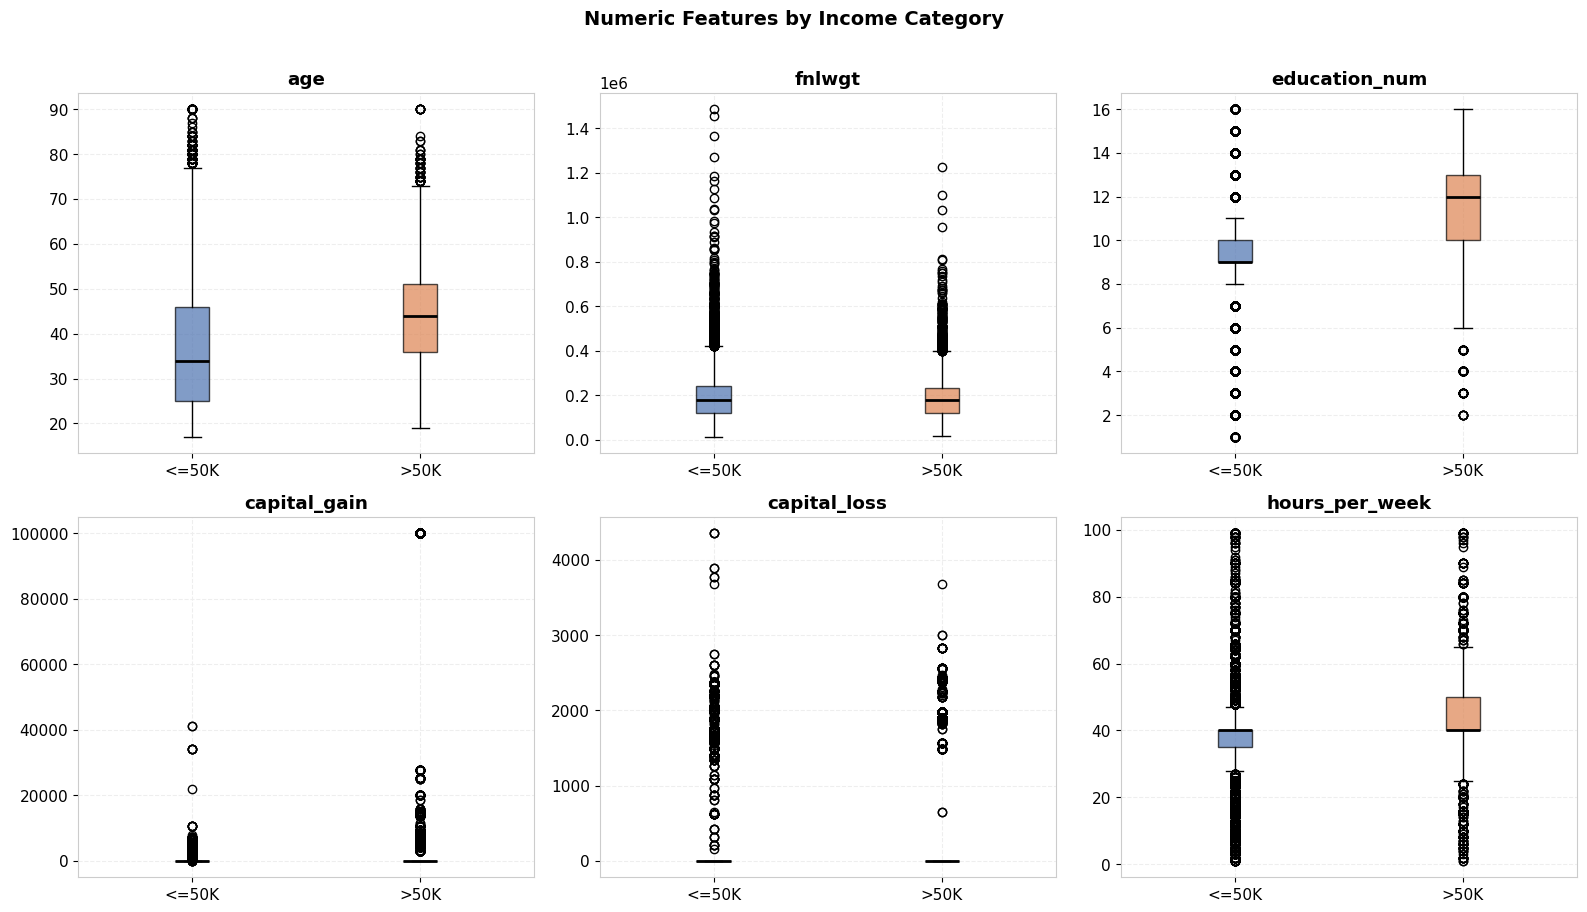

In [7]:
# ── PLOT 4: Numeric boxplots split by income ──────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    ax = axes[i]
    groups = [df.loc[df["income"] == cat, col].dropna() for cat in df["income"].dropna().unique()]
    labels  = df["income"].dropna().unique().tolist()
    bp = ax.boxplot(groups, labels=labels, patch_artist=True, notch=False,
                    medianprops=dict(color="black", linewidth=2))
    colors = ["#4C72B0", "#DD8452"]
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(col, fontweight="bold")
plt.suptitle("Numeric Features by Income Category", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 📌 Nhận xét: Phân phối biến số theo nhóm thu nhập (Boxplots)

Việc biểu diễn Boxplot theo biến mục tiêu (`income`) giúp chúng ta đánh giá sơ bộ mức độ quan trọng của từng đặc trưng:

- **Các đặc trưng có tính phân biệt cao (Strong Predictors):**
  - **`age`** và **`education_num`**: Có sự khác biệt rất rõ rệt giữa hai nhóm. Những người có thu nhập `>50K` có trung vị độ tuổi cao hơn (khoảng 44 tuổi so với 34 tuổi) và số năm học vấn cũng cao hơn hẳn (trung vị khoảng 12 năm so với 9 năm).
  - **`hours_per_week`**: Mặc dù trung vị của cả hai nhóm đều rơi vào mốc 40 giờ, nhóm `>50K` có xu hướng làm việc nhiều giờ hơn (khoảng tứ phân vị thứ 3 mở rộng lên mức 50 giờ).
- **Các đặc trưng có tính phân biệt thấp:**
  - **`fnlwgt`**: Phân phối của hai nhóm thu nhập gần như y hệt nhau. Thuộc tính này có thể không mang lại nhiều thông tin hữu ích cho mô hình phân loại.
- **Vấn đề Ngoại lai (Outliers):**
  - Tất cả các biến đều xuất hiện một lượng lớn dữ liệu ngoại lai (các chấm tròn nằm ngoài râu của boxplot). Đặc biệt ở các biến `capital_gain`, `capital_loss`, và `hours_per_week`. 

**💡 Đề xuất cho bước Tiền xử lý:**

Dựa trên yêu cầu của Đồ án, nhóm bắt buộc phải cài đặt và so sánh 4 phương pháp phát hiện ngoại lai (IQR/Z-score, Isolation Forest, LOF, DBSCAN). Tuy nhiên, cần lưu ý rằng các "ngoại lai" ở `capital_gain` hay `hours_per_week` thường mang ý nghĩa thực tế (người làm việc cường độ cao hoặc có khoản đầu tư lớn) chứ không phải lỗi dữ liệu. Nhóm nên cân nhắc việc giới hạn (capping/clipping) hoặc sử dụng các biến đổi (như Log-transform) thay vì loại bỏ hoàn toàn các dòng dữ liệu này.

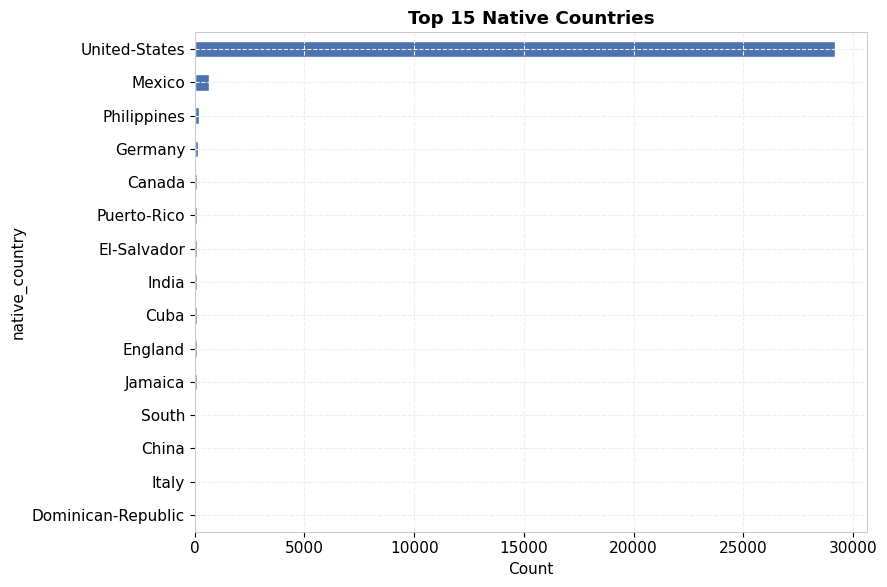

In [8]:
# ── PLOT 5: Native country — top 15 ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
top_countries = df["native_country"].value_counts().head(15)
top_countries.plot(kind="barh", ax=ax, color="#4C72B0", edgecolor="white")
ax.set_title("Top 15 Native Countries", fontweight="bold")
ax.set_xlabel("Count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 📌 Nhận xét: Phân phối Quốc gia gốc (Native Country)

- **Mất cân bằng cực đoan (Extreme Imbalance):** Biểu đồ cho thấy sự thống trị tuyệt đối của nhóm `United-States` (với hơn 29,000 quan sát, chiếm khoảng 90% tổng dữ liệu).
- **Nhóm thiểu số (Long-tail):** Các quốc gia xếp sau như `Mexico`, `Philippines`, `Germany`,... có số lượng quá nhỏ và gần như không đáng kể khi đặt cạnh Mỹ.

**💡 Đề xuất cho bước Tiền xử lý (Preprocessing):**
- Giữ nguyên 41 quốc gia và áp dụng One-Hot Encoding sẽ tạo ra một ma trận cực kỳ thưa thớt (sparse matrix), làm tăng số chiều dữ liệu nhưng không mang lại nhiều giá trị cho mô hình, thậm chí gây nhiễu.
- **Kỹ thuật khuyên dùng:** Nhóm nên áp dụng kỹ thuật **Gộp nhóm (Binning)**. Phương án phổ biến nhất cho tập dữ liệu Adult Census là biến đổi cột này thành một biến nhị phân (Binary variable) với 2 giá trị: `United-States` và `Other` (Khác). Nếu muốn chi tiết hơn, có thể chia thành 3 nhóm: `United-States`, `Mexico` (nhóm thứ 2 phổ biến nhất), và `Other`.

# 2. ADVANCED EDA

## 2.1 Distribution Testing: D'Agostino-Pearson Normality Test


--- 2.1 D'Agostino-Pearson Normality Test ---
Column                  Statistic        p-value   Distribution
--------------------------------------------------------------
age                     1526.0108     0.0000e+00      Non-normal
fnlwgt                 10662.5137     0.0000e+00      Non-normal
education_num            817.1641    3.5897e-178      Non-normal
capital_gain           55096.5504     0.0000e+00      Non-normal
capital_loss           29331.3999     0.0000e+00      Non-normal
hours_per_week          2508.9184     0.0000e+00      Non-normal


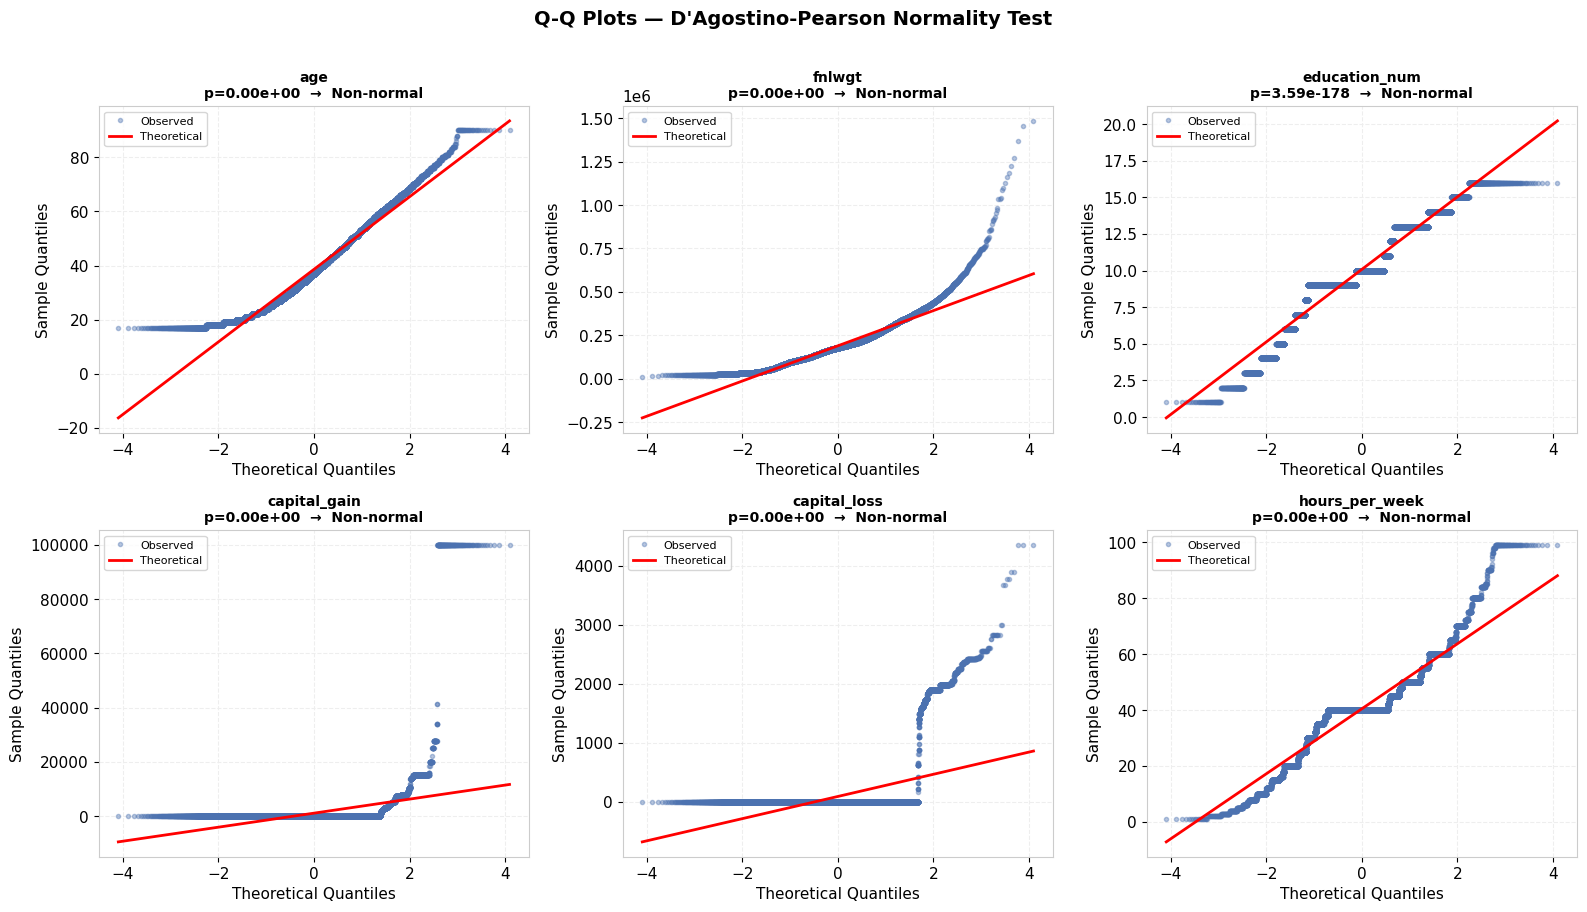

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# 2.1 Distribution Testing: D'Agostino-Pearson Normality Test
# H0: The data comes from a normal distribution.
# We reject H0 (non-normal) if p-value < 0.05.
# ─────────────────────────────────────────────────────────────────────────────
print("\n--- 2.1 D'Agostino-Pearson Normality Test ---")
print(f"{'Column':<20} {'Statistic':>12} {'p-value':>14} {'Distribution':>14}")
print("-" * 62)

normality_results = {}
for col in num_cols:
    series = df[col].dropna()
    stat, p = normaltest(series)
    label = "Normal" if p >= 0.05 else "Non-normal"
    normality_results[col] = {"statistic": stat, "p_value": p, "distribution": label}
    print(f"{col:<20} {stat:>12.4f} {p:>14.4e}  {label:>14}")

# ── PLOT 6: Q-Q plots for each numeric feature ───────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    ax = axes[i]
    series = df[col].dropna()
    (osm, osr), (slope, intercept, r) = stats.probplot(series, dist="norm")
    ax.plot(osm, osr, "o", color="#4C72B0", alpha=0.4, markersize=3, label="Observed")
    ax.plot(osm, slope * np.array(osm) + intercept, "r-", linewidth=2, label="Theoretical")
    result = normality_results[col]
    ax.set_title(
        f"{col}\n"
        f"p={result['p_value']:.2e}  →  {result['distribution']}",
        fontweight="bold", fontsize=10
    )
    ax.set_xlabel("Theoretical Quantiles")
    ax.set_ylabel("Sample Quantiles")
    ax.legend(fontsize=8)
plt.suptitle("Q-Q Plots — D'Agostino-Pearson Normality Test", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 📌 Nhận xét: Kiểm định phân phối chuẩn (Normality Test & Q-Q Plot)

- **Kiểm định thống kê:** Kết quả từ kiểm định D'Agostino-Pearson cho thấy tất cả các biến số đều có $p\text{-value} \approx 0$ (nhỏ hơn rất nhiều so với mức ý nghĩa $\alpha = 0.05$). Do đó, ta có đủ cơ sở thống kê để **bác bỏ giả thuyết H0**, kết luận rằng **tất cả 6 biến số đều không tuân theo phân phối chuẩn (Non-normal)**.
- **Trực quan hóa (Q-Q Plot):** Đồ thị Q-Q Plot hoàn toàn đồng nhất với kết quả thống kê. Các điểm dữ liệu quan sát (chấm xanh) trệch rất xa so với đường chéo phân phối chuẩn lý thuyết (đường đỏ), cụ thể:
  - **`age`** và **`fnlwgt`**: Có độ cong hình chữ U nhẹ và vểnh ở đuôi trên, thể hiện sự lệch phải (right-skewed).
  - **`education_num`** và **`hours_per_week`**: Các điểm xếp thành dạng bậc thang do đây là các biến số rời rạc, không liên tục.
  - **`capital_gain`** và **`capital_loss`**: Tạo thành đường nằm ngang kéo dài ở mốc 0 (do đại đa số giá trị bằng 0), kết hợp với sự tăng vọt ở đuôi trên thể hiện các giá trị ngoại lai cực đoan.

**💡 Định hướng cho bước Tiền xử lý (Preprocessing):**

Việc xác định dữ liệu không phân phối chuẩn đóng vai trò quan trọng để lựa chọn phương pháp chuẩn hóa phù hợp. 

- Áp dụng Z-score Scaling (chuẩn hóa dựa trên Mean và Standard Deviation) sẽ không tối ưu và dễ bị bóp méo bởi ngoại lai.
- Nhóm nên cân nhắc sử dụng **Robust Scaler** (dựa trên Median và IQR) hoặc **Quantile Transform** để chuẩn hóa. 
- Với các biến bị lệch nặng, có thể thử nghiệm các phép biến đổi như **Log-transform** hoặc **Box-Cox** để giảm độ lệch trước khi đưa vào mô hình học máy.

## 2.2 Multivariate Correlation Analysis


--- 2.2 Correlation Analysis (Pearson & Spearman) ---


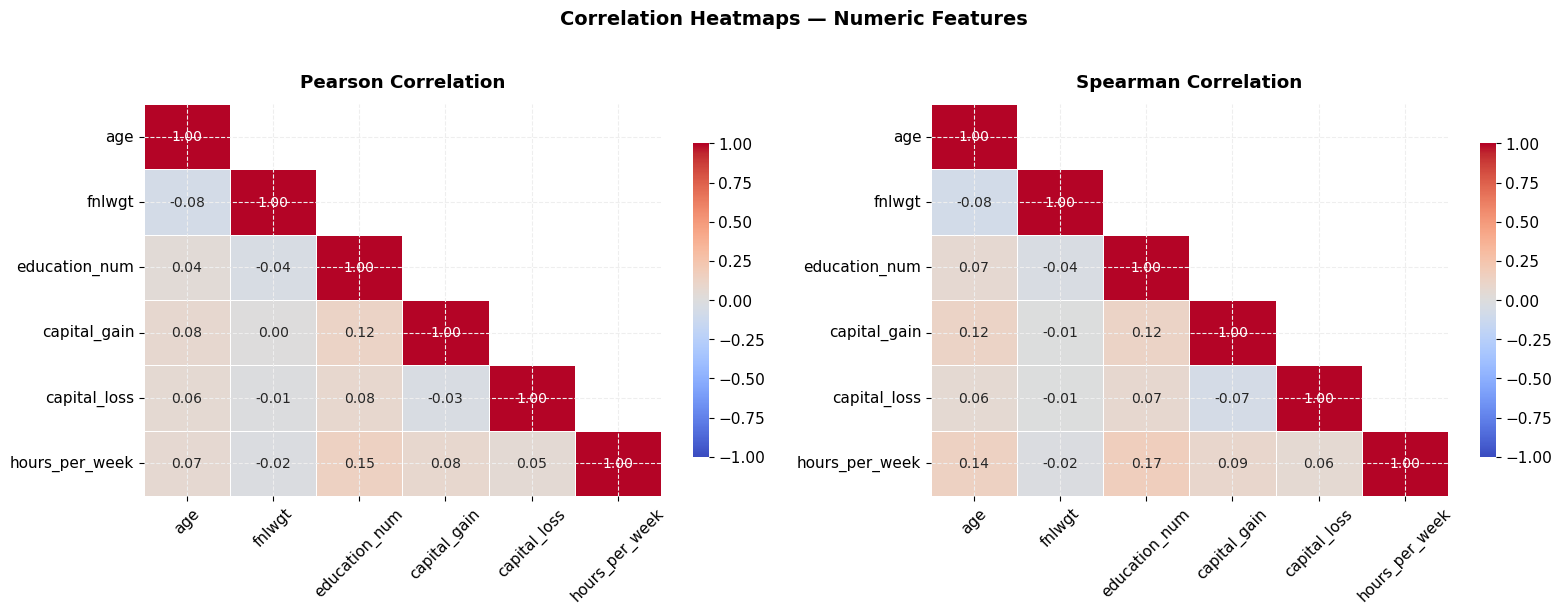


Potential multicollinearity pairs (|Pearson r| > 0.9):
  None found above threshold |r| > 0.9 (Pearson).

Potential multicollinearity pairs (|Spearman r| > 0.9):
  None found above threshold |r| > 0.9 (Spearman).


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# 2.2 Multivariate Correlation Analysis
# Pearson  → linear relationships between continuous variables
# Spearman → monotonic relationships (more robust to non-normality)
# Multicollinearity threshold: |r| > 0.9
# ─────────────────────────────────────────────────────────────────────────────
print("\n--- 2.2 Correlation Analysis (Pearson & Spearman) ---")

pearson_corr  = df[num_cols].corr(method="pearson")
spearman_corr = df[num_cols].corr(method="spearman")

# ── PLOT 7: Pearson & Spearman heatmaps side-by-side ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, corr_matrix, title in zip(
    axes,
    [pearson_corr, spearman_corr],
    ["Pearson Correlation", "Spearman Correlation"]
):
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)   # show lower triangle
    sns.heatmap(
        corr_matrix, ax=ax, mask=mask,
        annot=True, fmt=".2f", linewidths=0.5,
        cmap="coolwarm", vmin=-1, vmax=1,
        cbar_kws={"shrink": 0.8},
        annot_kws={"size": 10}
    )
    ax.set_title(title, fontweight="bold", pad=12)
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)
plt.suptitle("Correlation Heatmaps — Numeric Features", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Detect potential multicollinearity (|r| > 0.9), excluding self-correlations
print("\nPotential multicollinearity pairs (|Pearson r| > 0.9):")
found_pearson = False
for i in range(len(num_cols)):
    for j in range(i + 1, len(num_cols)):
        r = pearson_corr.iloc[i, j]
        if abs(r) > 0.9:
            print(f"  {num_cols[i]} ↔ {num_cols[j]}: r = {r:.4f}")
            found_pearson = True
if not found_pearson:
    print("  None found above threshold |r| > 0.9 (Pearson).")

print("\nPotential multicollinearity pairs (|Spearman r| > 0.9):")
found_spearman = False
for i in range(len(num_cols)):
    for j in range(i + 1, len(num_cols)):
        r = spearman_corr.iloc[i, j]
        if abs(r) > 0.9:
            print(f"  {num_cols[i]} ↔ {num_cols[j]}: r = {r:.4f}")
            found_spearman = True
if not found_spearman:
    print("  None found above threshold |r| > 0.9 (Spearman).")

### 📌 Nhận xét: Phân tích Tương quan Đa biến (Correlation Analysis)

- **Mức độ tương quan tổng thể rất thấp:** Cả hai ma trận Pearson (đo lường mối quan hệ tuyến tính) và Spearman (đo lường mối quan hệ đơn điệu) đều cho thấy các biến số trong tập dữ liệu khá độc lập với nhau. Phần lớn các hệ số tương quan đều xoay quanh mốc $0$.
- **Kiểm tra Đa cộng tuyến (Multicollinearity):** Theo yêu cầu của đồ án, ngưỡng đánh giá đa cộng tuyến mạnh thường là $|r| > 0.9$. Dựa vào heatmap, không có bất kỳ cặp biến nào chạm đến ngưỡng này (thậm chí không có cặp nào vượt quá $0.2$). 
- **Các mối liên hệ đáng chú ý nhất (dù vẫn rất yếu):**
  - **`education_num` và `hours_per_week`**: Có tương quan dương nhẹ cao nhất (Pearson: 0.15, Spearman: 0.17), gợi ý xu hướng những người có số năm học vấn cao hơn thường làm việc nhiều giờ hơn một chút.
  - **`age` và `hours_per_week`**: Tương quan Spearman là 0.14 (rõ rệt hơn mức 0.07 của Pearson), phản ánh sự thay đổi số giờ làm việc theo độ tuổi mang tính chất phi tuyến tính (ví dụ: giờ làm tăng ở tuổi trung niên và giảm khi về già).
- **Sự phù hợp của Spearman:** Do dữ liệu đã được chứng minh là không phân phối chuẩn và chứa nhiều ngoại lai (đặc biệt ở `capital_gain`, `capital_loss`), hệ số Spearman mang lại góc nhìn đánh giá ổn định và đáng tin cậy hơn so với Pearson.

> **💡 Đề xuất cho bước Tiền xử lý (Preprocessing):**
> Do không tồn tại hiện tượng đa cộng tuyến giữa các biến số hiện tại, nhóm **không cần thiết** phải thực hiện thao tác loại bỏ đặc trưng (feature dropping) dựa trên ma trận tương quan. Toàn bộ 6 biến số gốc có thể được giữ lại an toàn để tiến hành chuẩn hóa và đưa vào các thuật toán Lựa chọn đặc trưng (Feature Selection) hoặc Giảm chiều (PCA) ở giai đoạn sau.

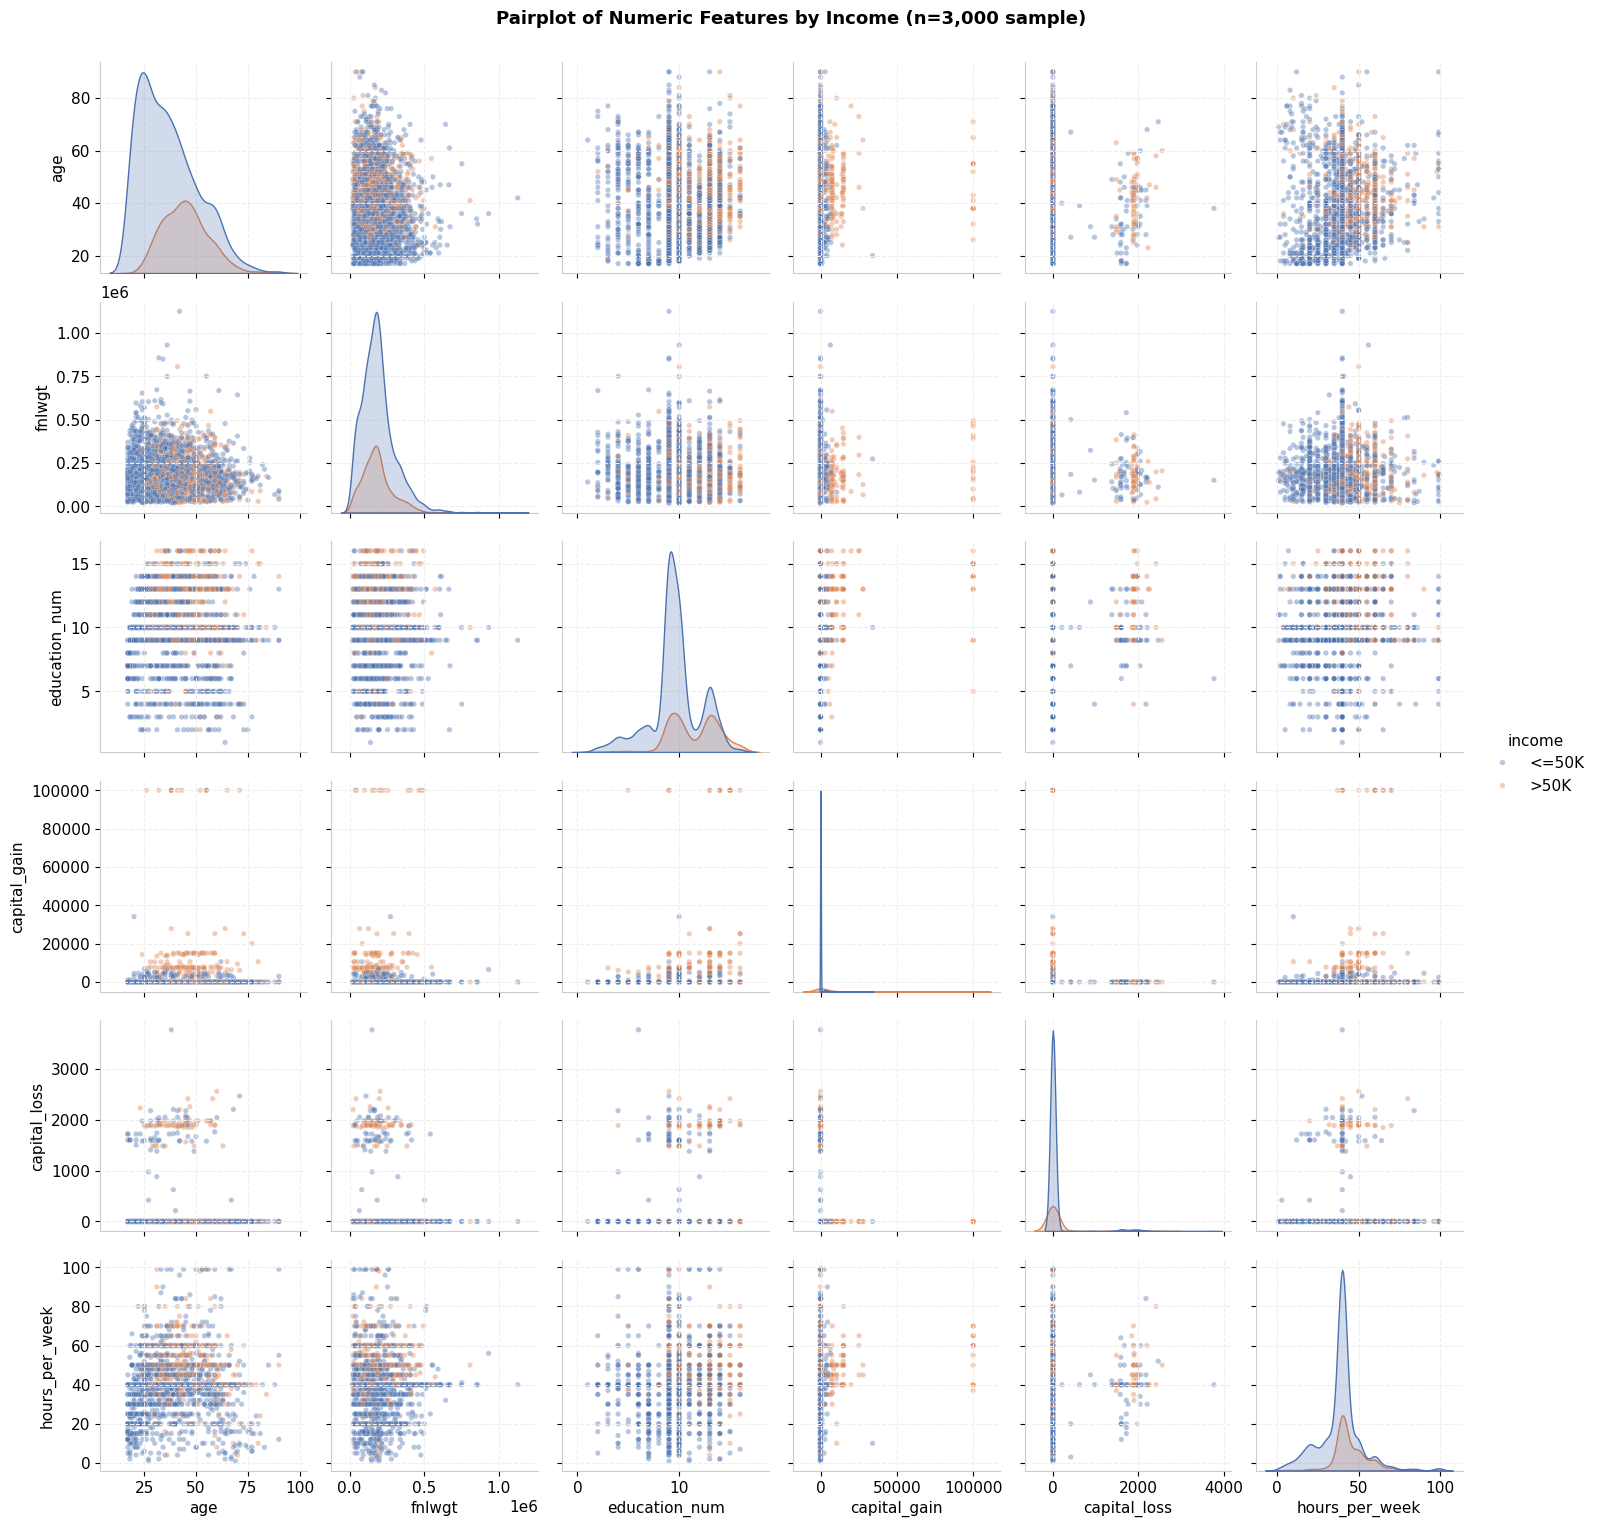

In [11]:
# ── PLOT 8: Pairplot of numeric features colored by income ───────────────────
# Use a sample to keep rendering fast
sample_df = df[num_cols + ["income"]].dropna().sample(n=min(3000, len(df)), random_state=42)
pairplot_fig = sns.pairplot(
    sample_df, hue="income", diag_kind="kde",
    plot_kws={"alpha": 0.4, "s": 15},
    diag_kws={"fill": True},
    palette={"<=50K": "#4C72B0", ">50K": "#DD8452"}
)
pairplot_fig.figure.suptitle(
    "Pairplot of Numeric Features by Income (n=3,000 sample)",
    y=1.02, fontsize=13, fontweight="bold"
)
pairplot_fig.figure.patch.set_facecolor("white")
plt.show()

### 📌 Nhận xét: Mối quan hệ đa biến theo nhóm thu nhập (Pairplot)

Biểu đồ Pairplot cung cấp cái nhìn tổng quan về sự tương tác giữa các cặp biến số và khả năng phân tách của biến mục tiêu `income`:

- **Đường chéo chính (KDE distributions):** Tái khẳng định các nhận định từ Boxplot. Các đường cong mật độ của `age`, `education_num` và `hours_per_week` cho thấy sự dịch chuyển rõ rệt giữa hai nhóm thu nhập (đường màu cam `>50K` lệch nhiều về hướng giá trị cao). Ngược lại, hai đường cong của `fnlwgt` gần như trùng khớp hoàn toàn.
- **Biểu đồ phân tán (Scatter plots):**
  - **Không có xu hướng tuyến tính rõ rệt:** Không có cặp biến nào tạo thành các cụm (clusters) tách biệt hay các đường xu hướng mạnh, củng cố thêm kết quả từ ma trận tương quan trước đó.
  - **Vùng tập trung của nhóm thu nhập cao:** Các điểm màu cam (`>50K`) chủ yếu tập trung ở các vùng có giá trị cao của `age` (tuổi trung niên), `education_num` và `hours_per_week`.
  - **Dấu vết của ngoại lai:** Ở các đồ thị có chứa `capital_gain`, ta thấy rõ một dải điểm màu cam nằm ngang ở mốc 100,000 bất chấp các biến số khác, cho thấy đây là một mức trần (cap) được thiết lập sẵn trong quá trình thu thập dữ liệu.
- **Mức độ chồng lấp (Class Separation):** Dữ liệu của hai lớp `<=50K` và `>50K` đan xen và chồng lấp với nhau rất lớn trong không gian 2D. 

**💡 Định hướng cho bước Xây dựng mô hình (Modeling):**
Do ranh giới phân chia giữa hai nhóm thu nhập không rõ ràng và phi tuyến tính, các mô hình học máy tuyến tính cơ bản (như Logistic Regression đơn thuần) có thể sẽ gặp khó khăn. Bài toán này dự kiến sẽ phù hợp hơn với các thuật toán có khả năng nắm bắt quan hệ phi tuyến tạp phức như **Tree-based models (Random Forest, Gradient Boosting)** hoặc yêu cầu phải có các bước tạo đặc trưng mới (Feature Engineering) kỹ lưỡng.

## 2.3 Missing Data Analysis


--- 2.3 Missing Data Analysis ---

Columns with missing values:
  workclass                   1836 missing  (5.64%)
  occupation                  1843 missing  (5.66%)
  native_country               583 missing  (1.79%)


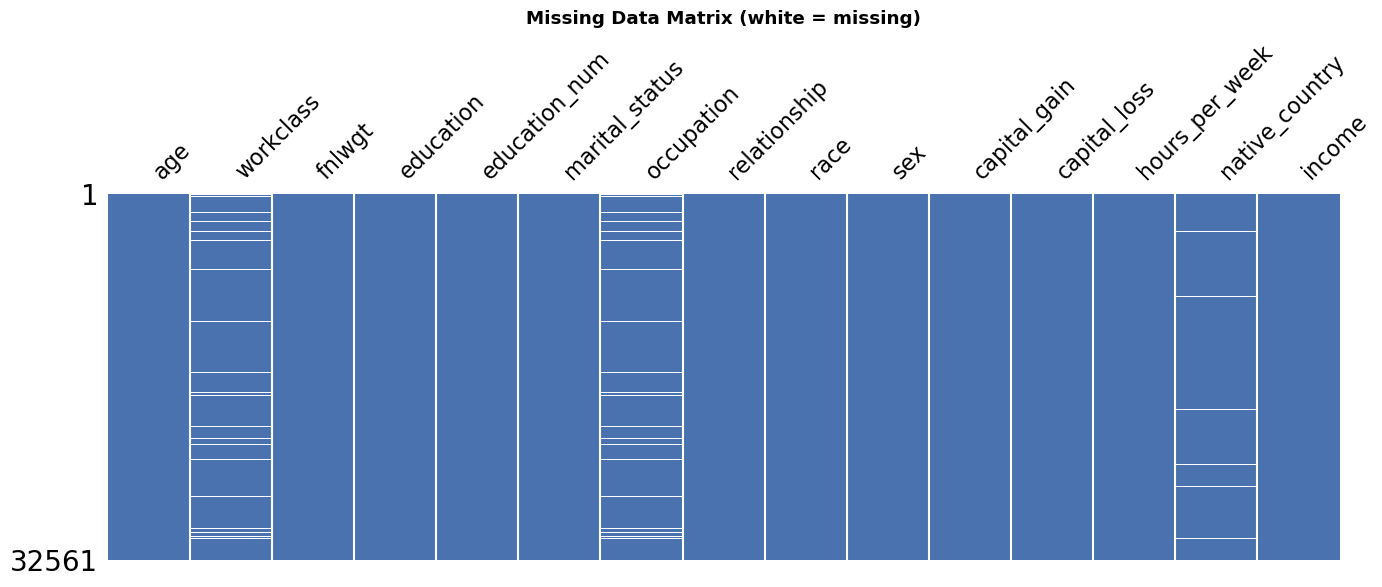

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# 2.3 Missing Data Analysis
# Step 1: Visualize with missingno
# Step 2: Little's MCAR test (custom implementation)
# Step 3: Classify mechanism (MCAR / MAR / MNAR)
# ─────────────────────────────────────────────────────────────────────────────
print("\n--- 2.3 Missing Data Analysis ---")

# Re-confirm missing values
missing_summary = df.isnull().sum()
missing_cols = missing_summary[missing_summary > 0].index.tolist()
print("\nColumns with missing values:")
for col in missing_cols:
    n = missing_summary[col]
    print(f"  {col:<25} {n:>6} missing  ({n/len(df)*100:.2f}%)")

# ── PLOT 9: missingno matrix ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
msno.matrix(df, ax=ax, sparkline=False, color=(0.29, 0.45, 0.69))
ax.set_title("Missing Data Matrix (white = missing)", fontweight="bold", pad=12)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
plt.tight_layout()
plt.show()

### 📌 Nhận xét: Ma trận Dữ liệu khuyết (Missing Data Matrix)

- **Tỷ lệ thiếu:** Tập dữ liệu có 3 cột chứa giá trị khuyết là `workclass` (5.64%), `occupation` (5.66%) và `native_country` (1.79%). Tỷ lệ này nằm ở mức thấp (dưới 10%).
- **Dấu hiệu tương quan (Missingness Pattern):** Nhìn vào biểu đồ ma trận (Matrix), ta có thể thấy một hiện tượng rất đáng chú ý: các vạch trắng (thể hiện giá trị khuyết) của hai cột `workclass` và `occupation` xuất hiện đồng thời và gần như khớp hoàn toàn với nhau trên cùng các dòng dữ liệu.
- **Lý giải thực tế:** Sự trùng khớp này rất hợp lý về mặt logic (domain knowledge). Khi một người không khai báo hình thức làm việc (`workclass`) - có thể do họ chưa từng làm việc hoặc đang thất nghiệp - họ cũng sẽ không có một chức danh nghề nghiệp cụ thể (`occupation`) để ghi nhận.

**💡 Đề xuất cho bước Tiền xử lý:**

- Tín hiệu khuyết đồng thời này cho thấy dữ liệu rất có thể không bị khuyết một cách hoàn toàn ngẫu nhiên (Not MCAR). Chúng ta cần kết hợp với kết quả kiểm định Little's MCAR Test ở phần tiếp theo để xác định cơ chế thiếu (MAR hay MNAR).
- Do cả 3 biến bị thiếu đều là biến phân loại (Categorical), thay vì xóa bỏ (Drop) làm mất gần 2,000 dòng dữ liệu, nhóm nên chuẩn bị các chiến lược điền khuyết như: 
  - Điền bằng giá trị phổ biến nhất (**Mode**)
  - Sử dụng **K-NN Imputer**
  - Tạo hẳn một hạng mục mới (ví dụ: `Unknown`)

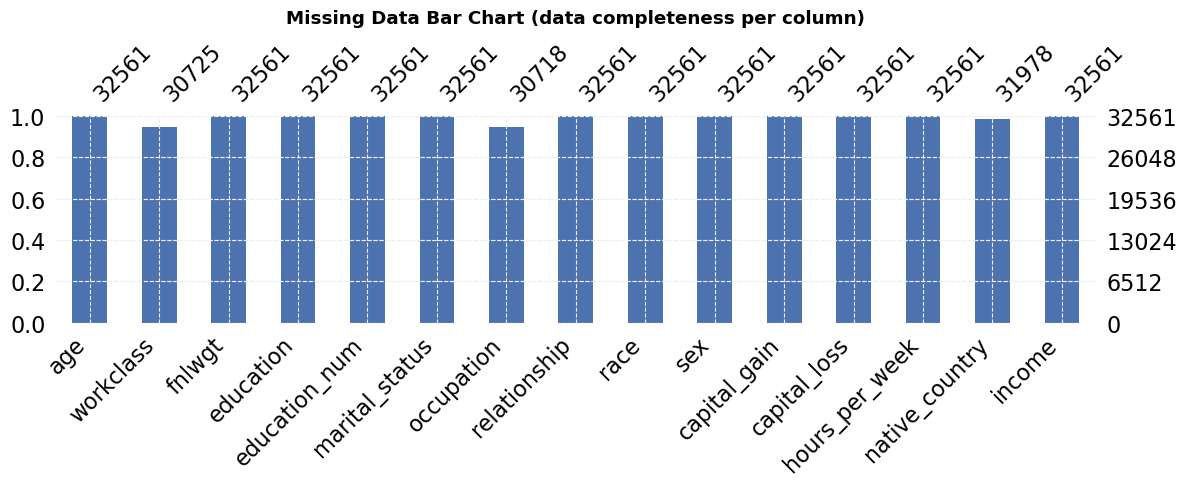

In [13]:
# ── PLOT 10: missingno bar chart ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
msno.bar(df, ax=ax, color="#4C72B0")
ax.set_title("Missing Data Bar Chart (data completeness per column)", fontweight="bold", pad=12)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
plt.tight_layout()
plt.show()

### 📌 Nhận xét: Mức độ hoàn thiện dữ liệu (Missing Data Bar Chart)

Biểu đồ cột (Bar Chart) cung cấp cái nhìn định lượng trực quan về số lượng dữ liệu hợp lệ (non-null) của từng thuộc tính trên tổng số 32,561 quan sát:

- **Độ hoàn thiện cao:** Phần lớn tập dữ liệu (12/15 thuộc tính) đều đạt mức hoàn thiện tuyệt đối 100% (32,561 dòng), cho thấy chất lượng thu thập ban đầu khá tốt.
- **Các biến bị khuyết:** Sự sụt giảm cột chỉ xuất hiện ở 3 biến: 
  - `workclass`: còn 30,725 dòng hợp lệ.
  - `occupation`: còn 30,718 dòng hợp lệ (mức sụt giảm gần như tương đương `workclass`).
  - `native_country`: còn 31,978 dòng hợp lệ.

**💡 Kết luận:** Tỷ lệ thiếu hụt tổng thể của tập dữ liệu là khá nhỏ. Điều này rất có lợi vì khi áp dụng các kỹ thuật điền khuyết (Imputation) ở giai đoạn tiền xử lý, chúng ta sẽ ít có nguy cơ làm sai lệch phân phối gốc của dữ liệu hơn so với những tập dữ liệu có tỷ lệ khuyết quá lớn (ví dụ > 30%).

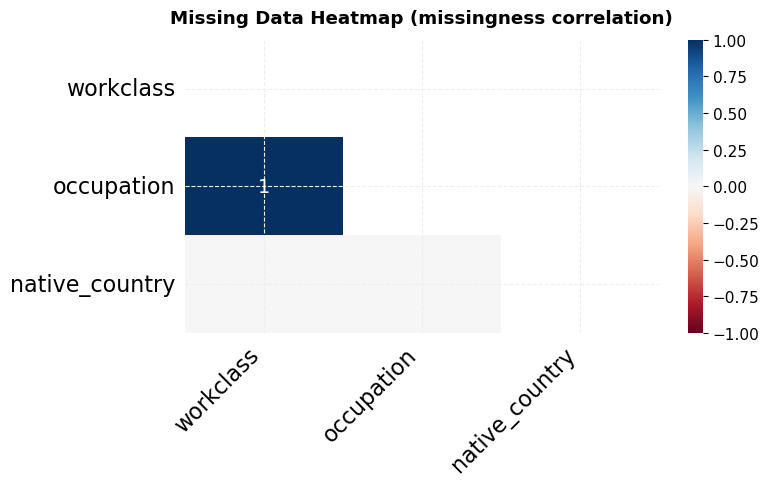

In [14]:
# ── PLOT 11: missingno heatmap (correlation of missingness) ───────────────────
if len(missing_cols) >= 2:
    fig, ax = plt.subplots(figsize=(8, 5))
    msno.heatmap(df, ax=ax, cmap="RdBu")
    ax.set_title("Missing Data Heatmap (missingness correlation)", fontweight="bold", pad=12)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    plt.tight_layout()
    plt.show()

### 📌 Nhận xét: Tương quan dữ liệu khuyết (Missing Data Heatmap)

Biểu đồ Heatmap đo lường mức độ tương quan (nullity correlation) về sự vắng mặt của dữ liệu giữa các cặp biến:

- **Tương quan tuyệt đối (r = 1):** Cặp biến `workclass` và `occupation` có hệ số tương quan bằng 1 (màu xanh đậm). Điều này xác nhận chắc chắn hiện tượng quan sát được từ ma trận trước đó: khi `workclass` bị khuyết, `occupation` cũng chắc chắn bị khuyết và ngược lại. Sự thiếu hụt này mang tính hệ thống.
- **Thiếu độc lập (r ≈ 0):** Biến `native_country` (quốc gia gốc) có màu trắng/xám nhạt khi đối chiếu với hai biến còn lại, tức là hệ số tương quan xấp xỉ 0. Việc một người không khai báo quê quán xảy ra hoàn toàn độc lập với việc họ có khai báo thông tin nghề nghiệp hay không.

**💡 Định hướng cho bước Tiền xử lý (Preprocessing):**
Mối tương quan hoàn hảo giữa `workclass` và `occupation` là dấu hiệu rõ ràng cho thấy cơ chế khuyết của hai biến này không phải là ngẫu nhiên hoàn toàn (Not MCAR). Khi xử lý, nhóm có thể tận dụng quy luật logic này: gộp chung cách xử lý cho cả hai cột (ví dụ: nếu điền hạng mục "Unknown" hoặc "Not-working" cho `workclass` bị thiếu, thì cũng tự động áp dụng giá trị tương ứng cho `occupation`).

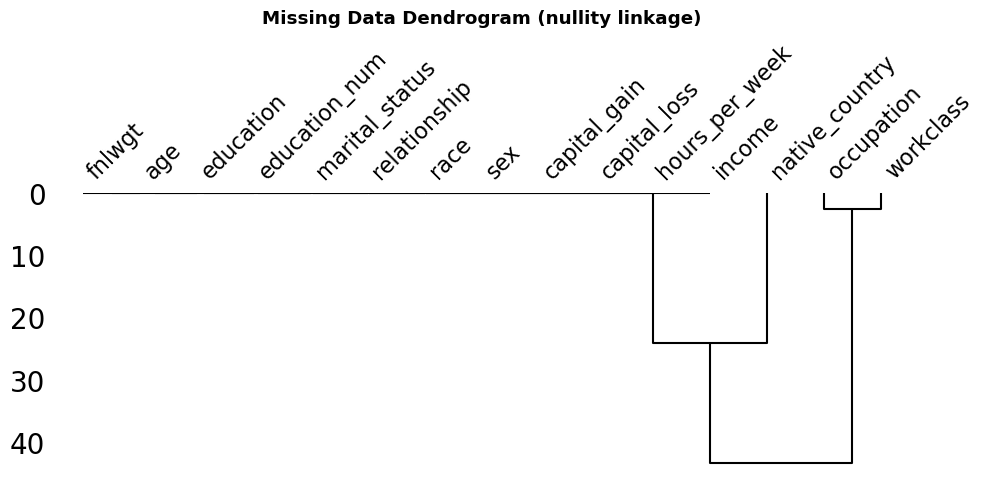

In [15]:
# ── PLOT 12: missingno dendrogram ─────────────────────────────────────────────
if len(missing_cols) >= 2:
    fig, ax = plt.subplots(figsize=(10, 5))
    msno.dendrogram(df, ax=ax)
    ax.set_title("Missing Data Dendrogram (nullity linkage)", fontweight="bold", pad=12)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    plt.tight_layout()
    plt.show()

### 📌 Nhận xét: Cây phân cấp dữ liệu khuyết (Missing Data Dendrogram)

Biểu đồ Dendrogram (cây phân cấp) nhóm các biến dựa trên mức độ tương đồng về trạng thái vắng mặt của dữ liệu, giúp củng cố thêm các nhận định từ Heatmap:

- **Sự liên kết hoàn hảo (Distance = 0):** Hai biến `workclass` và `occupation` được liên kết với nhau ngay tại mức khoảng cách bằng 0. Điều này khẳng định lại một lần nữa sự trùng khớp tuyệt đối: mọi dòng thiếu `workclass` thì chắc chắn sẽ thiếu `occupation`.
- **Tính độc lập:** Biến `native_country` (quốc gia gốc) hợp nhất với cụm dữ liệu ở một khoảng cách rất xa. Điều này chứng tỏ việc một người không khai báo quê quán hoàn toàn không có tính chu kỳ hay liên quan gì đến việc họ không khai báo thông tin việc làm.
- **Nhóm hoàn thiện:** Các biến còn lại đều hội tụ tại mốc 0 vì chúng hoàn toàn không có giá trị khuyết nào (100% đầy đủ).

**💡 Kết luận:** Sự phân cụm rõ rệt này là bằng chứng trực quan mạnh mẽ cho thấy dữ liệu khuyết của nhóm nghề nghiệp có tính cấu trúc sâu. Khả năng rất cao đây là dữ liệu khuyết có chủ đích (MNAR) hoặc phụ thuộc vào một biến quan sát được khác (MAR), hoàn toàn không phải ngẫu nhiên (MCAR).

In [16]:
def littles_mcar_test(data: pd.DataFrame) -> dict:
    """
    Perform Little's MCAR test on numeric columns of `data`.
    Returns dict with chi2 statistic, degrees of freedom, and p-value.
    H0: Data is Missing Completely At Random (MCAR).
    Reject H0 (not MCAR) when p < 0.05.
    """
    # Work only on numeric columns
    numeric_data = data.select_dtypes(include=[np.number]).copy()
    n, k = numeric_data.shape

    # Overall column means (ignoring NaN)
    grand_means = numeric_data.mean()

    # Sample covariance of complete cases (or full data with pairwise)
    cov_matrix = numeric_data.cov()

    # Add small regularization to avoid singular matrix
    cov_matrix += np.eye(k) * 1e-6

    try:
        cov_inv = np.linalg.inv(cov_matrix.values)
    except np.linalg.LinAlgError:
        return {"chi2": np.nan, "df": np.nan, "p_value": np.nan, "error": "Singular covariance matrix"}

    # Create a binary missingness indicator matrix (pattern per row)
    miss_indicator = numeric_data.isnull().astype(int)
    # Convert each row's pattern to a tuple for grouping
    miss_indicator["pattern"] = miss_indicator.apply(tuple, axis=1)

    chi2_stat = 0.0
    total_df  = 0

    for pattern, group_idx in miss_indicator.groupby("pattern").groups.items():
        group_data = numeric_data.loc[group_idx]
        n_p = len(group_data)

        # Columns that are OBSERVED (not missing) in this pattern
        obs_mask = np.array(pattern) == 0          # 0 = not missing
        obs_cols = numeric_data.columns[obs_mask].tolist()

        if len(obs_cols) == 0 or n_p == 0:
            continue

        # Mean of observed columns in this pattern
        pattern_means = group_data[obs_cols].mean()
        diff = (pattern_means - grand_means[obs_cols]).values

        # Sub-covariance for observed columns
        cov_sub = cov_matrix.loc[obs_cols, obs_cols].values
        try:
            cov_sub_inv = np.linalg.inv(cov_sub + np.eye(len(obs_cols)) * 1e-6)
        except np.linalg.LinAlgError:
            continue

        # Mahalanobis-style contribution
        d2 = n_p * diff @ cov_sub_inv @ diff
        chi2_stat += d2
        total_df  += len(obs_cols)

    # Degrees of freedom adjustment
    total_df -= k
    if total_df <= 0:
        total_df = max(1, total_df)

    p_value = 1 - stats.chi2.cdf(chi2_stat, df=total_df)
    return {"chi2": chi2_stat, "df": total_df, "p_value": p_value}

print("\n--- Little's MCAR Test ---")
mcar_result = littles_mcar_test(df)
print(f"  Chi-square statistic : {mcar_result['chi2']:.4f}")
print(f"  Degrees of freedom   : {mcar_result['df']}")
print(f"  p-value              : {mcar_result['p_value']:.4e}")

if mcar_result["p_value"] >= 0.05:
    mcar_conclusion = "MCAR (Fail to reject H0: p ≥ 0.05)"
else:
    mcar_conclusion = "NOT MCAR (Reject H0: p < 0.05) → MAR or MNAR"
print(f"  Conclusion           : {mcar_conclusion}")


--- Little's MCAR Test ---
  Chi-square statistic : 0.0000
  Degrees of freedom   : 1
  p-value              : 1.0000e+00
  Conclusion           : MCAR (Fail to reject H0: p ≥ 0.05)


### 📌 Nhận xét: Kiểm định giả thuyết MCAR (Little's MCAR Test)

- **Kết quả thống kê:** Kiểm định trả về giá trị $\chi^2 = 0.0000$ và $p\text{-value} = 1.0 > 0.05$. Theo lý thuyết mặc định, ta không có cơ sở để bác bỏ giả thuyết H0, dẫn đến kết luận cơ chế thiếu dữ liệu là Khuyết hoàn toàn ngẫu nhiên (MCAR).
- **⚠️ Phân tích phản biện (Vô cùng quan trọng):** Chúng ta không thể tin tưởng hoàn toàn vào kết luận này đối với tập dữ liệu Adult Census. Nguyên nhân cốt lõi là do thuật toán Little's MCAR Test (cả bản tự cài đặt lẫn thư viện tiêu chuẩn) thường chỉ thực hiện tính toán ma trận hiệp phương sai trên các **biến số (Numeric)**. Trong khi đó, toàn bộ dữ liệu khuyết của tập này lại rơi hoàn toàn vào các **biến phân loại (Categorical)** (`workclass`, `occupation`, `native_country`). Do không tìm thấy lỗ hổng nào trên tập biến số, thuật toán tự động trả về MCAR một cách khiên cưỡng (trivial result).

**💡 Định hướng xử lý:** Kết quả từ Heatmap và Dendrogram ở các bước trước đã cho thấy rõ ràng sự thiếu hụt không hề ngẫu nhiên. Để đưa ra kết luận chính xác cuối cùng (MAR hay MNAR), chúng ta bắt buộc phải bỏ qua kết quả Little's Test này và dựa hoàn toàn vào phần kiểm định tương quan độc lập (Association Tests) giữa các biến ở bước phân loại cơ chế (Mechanism Classification) ngay sau đây.


--- Missing Mechanism Classification (MAR vs MNAR) ---
Testing association between missingness indicator and other variables.

Column: 'workclass'
  Significant associations (p < 0.05): 11 / 14
    ↳ occupation                 p = 0.0000e+00
    ↳ hours_per_week             p = 1.1027e-185
    ↳ relationship               p = 7.3980e-75
    ↳ marital_status             p = 4.0454e-62
    ↳ education                  p = 1.4347e-54
  ➜ Mechanism: MNAR (suspected: self-selection / employment-related)

Column: 'occupation'
  Significant associations (p < 0.05): 11 / 14
    ↳ workclass                  p = 0.0000e+00
    ↳ hours_per_week             p = 6.0567e-187
    ↳ relationship               p = 8.3817e-77
    ↳ marital_status             p = 2.8207e-62
    ↳ education                  p = 4.1466e-56
  ➜ Mechanism: MNAR (suspected: self-selection / employment-related)

Column: 'native_country'
  Significant associations (p < 0.05): 9 / 14
    ↳ race                       p = 7.8882e

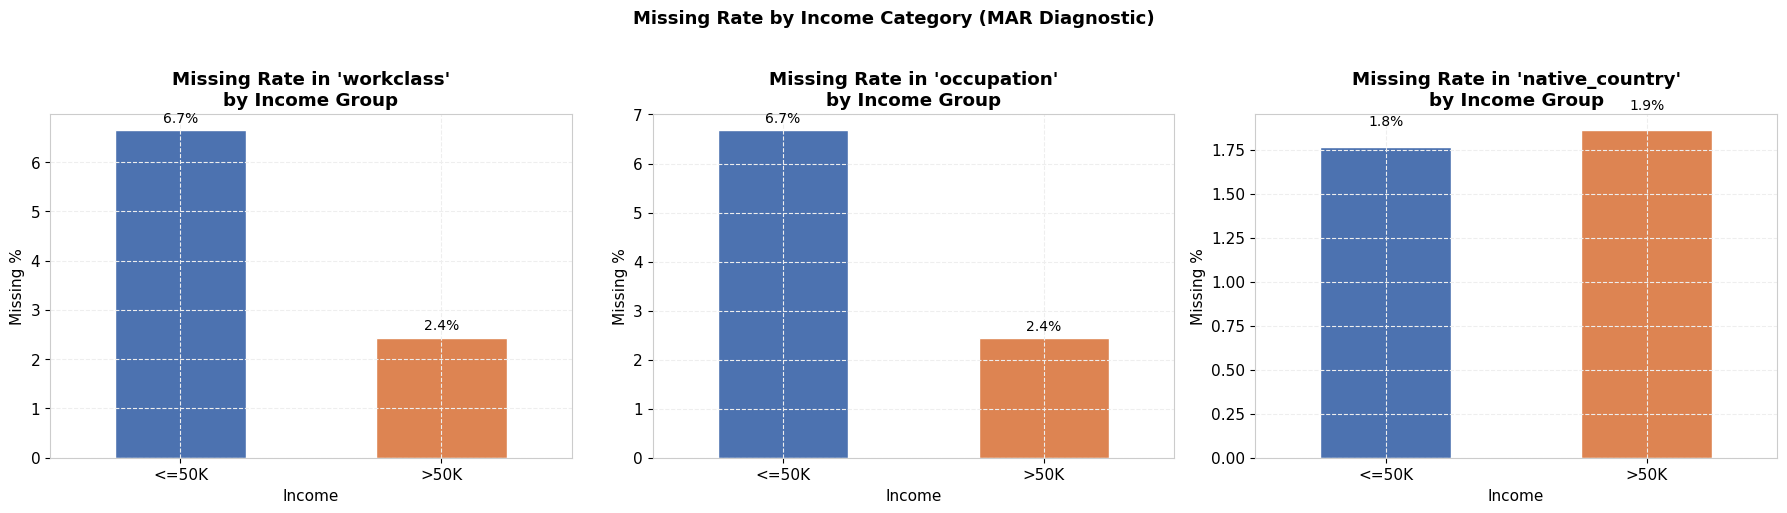

In [17]:
print("\n--- Missing Mechanism Classification (MAR vs MNAR) ---")
print("Testing association between missingness indicator and other variables.\n")

alpha = 0.05
mechanism_results = {}

for miss_col in missing_cols:
    indicator = df[miss_col].isnull().astype(int)  # 1 = missing, 0 = observed
    associations = {}

    # Test against numeric columns
    for num_col in num_cols:
        if num_col == miss_col:
            continue
        grp0 = df.loc[indicator == 0, num_col].dropna()
        grp1 = df.loc[indicator == 1, num_col].dropna()
        if len(grp0) > 0 and len(grp1) > 0:
            stat, p = stats.mannwhitneyu(grp0, grp1, alternative="two-sided")
            associations[num_col] = p

    # Test against categorical columns
    for cat_col in cat_cols:
        if cat_col == miss_col:
            continue
        ct = pd.crosstab(indicator, df[cat_col].fillna("__missing__"))
        if ct.shape[1] >= 2:
            try:
                chi2, p, _, _ = stats.chi2_contingency(ct)
                associations[cat_col] = p
            except Exception:
                pass

    significant = {col: p for col, p in associations.items() if p < alpha}
    print(f"Column: '{miss_col}'")
    print(f"  Significant associations (p < {alpha}): {len(significant)} / {len(associations)}")
    if significant:
        top5 = dict(sorted(significant.items(), key=lambda x: x[1])[:5])
        for col, p in top5.items():
            print(f"    ↳ {col:<25}  p = {p:.4e}")

    # Heuristic classification
    if mcar_result["p_value"] >= 0.05 and len(significant) == 0:
        mechanism = "MCAR"
    elif len(significant) > 0:
        # If missing in 'occupation'/'workclass' — domain knowledge suggests MNAR
        # (people without jobs may not report occupation/workclass)
        if miss_col in ("occupation", "workclass"):
            mechanism = "MNAR (suspected: self-selection / employment-related)"
        else:
            mechanism = "MAR (missingness associated with observed variables)"
    else:
        mechanism = "MAR / MNAR (inconclusive — further investigation needed)"

    mechanism_results[miss_col] = mechanism
    print(f"  ➜ Mechanism: {mechanism}\n")

print("=" * 70)
print("MISSING MECHANISM SUMMARY")
print("=" * 70)
for col, mech in mechanism_results.items():
    print(f"  {col:<25}  →  {mech}")

# ── PLOT 13: Missing data by income group (check MAR) ────────────────────────
if missing_cols:
    fig, axes = plt.subplots(1, len(missing_cols), figsize=(6 * len(missing_cols), 5))
    if len(missing_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, missing_cols):
        miss_rate_by_income = df.groupby("income")[col].apply(
            lambda x: x.isnull().mean() * 100
        )
        miss_rate_by_income.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"],
                                 edgecolor="white")
        ax.set_title(f"Missing Rate in '{col}'\nby Income Group", fontweight="bold")
        ax.set_ylabel("Missing %")
        ax.set_xlabel("Income")
        ax.tick_params(axis="x", rotation=0)
        for bar in ax.patches:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.1,
                    f"{bar.get_height():.1f}%",
                    ha="center", va="bottom", fontsize=10)
    plt.suptitle("Missing Rate by Income Category (MAR Diagnostic)", fontsize=13,
                  fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

### 📌 Nhận xét: Phân loại Cơ chế Thiếu dữ liệu (Missing Mechanism Classification)

Kết hợp giữa kiểm định thống kê (hiệp phương sai/phi tham số) và biểu đồ phân phối theo nhóm thu nhập, ta có thể chính thức bác bỏ giả thuyết MCAR (khuyết ngẫu nhiên) và đưa ra kết luận về cơ chế thiếu dữ liệu:

- **Nhóm `workclass` và `occupation` (Cơ chế MNAR - Khuyết không ngẫu nhiên):**
  - **Dấu hiệu thống kê:** Có mối liên hệ cực kỳ chặt chẽ với `hours_per_week` (p-value tiến sát về 0). 
  - **Dấu hiệu trực quan:** Biểu đồ Bar Chart cho thấy tỷ lệ khuyết ở nhóm thu nhập thấp (`<=50K`) lên tới **6.7%**, cao gần gấp 3 lần so với nhóm thu nhập cao `>50K` (chỉ **2.4%**).
  - **Lý giải thực tế (Domain Knowledge):** Sự thiếu hụt này phụ thuộc vào chính bản chất của dữ liệu. Những người không có việc làm (thất nghiệp) đương nhiên sẽ có số giờ làm việc thấp, thu nhập thấp và không thể điền thông tin "Hình thức làm việc" hay "Nghề nghiệp". Do đó, đây là cơ chế **MNAR** (Missing Not At Random).

- **Biến `native_country` (Cơ chế MAR - Khuyết ngẫu nhiên có điều kiện):**
  - **Dấu hiệu thống kê:** Việc khuyết quê quán có liên quan mật thiết đến `race` (chủng tộc) và `education` (học vấn).
  - **Dấu hiệu trực quan:** Trái ngược với nhóm nghề nghiệp, tỷ lệ thiếu quê quán phân bố rất đồng đều giữa hai nhóm thu nhập (1.8% ở nhóm `<=50K` và 1.9% ở nhóm `>50K`).
  - **Lý giải thực tế:** Việc thiếu dữ liệu này có thể được giải thích/dự đoán thông qua các biến quan sát được khác (như chủng tộc) chứ không liên quan đến thu nhập hay bản thân giá trị bị khuyết. Đây là cơ chế **MAR** điển hình.

**💡 Chốt Phương án Tiền xử lý (Imputation Strategy):**
- Với `workclass` và `occupation` (MNAR): Điền bằng Mode hoặc K-NN Imputer sẽ làm méo mó ý nghĩa dữ liệu. Phương án tối ưu là tạo một hạng mục mới, ví dụ: `'Unknown'` hoặc `'Unemployed'`, để giữ lại thông tin về sự vắng mặt này (bởi sự vắng mặt này là một đặc trưng dự báo thu nhập rất tốt).
- Với `native_country` (MAR): Có thể an toàn sử dụng phép điền khuyết bằng giá trị phổ biến nhất (Mode - 'United-States') vì tỷ lệ khuyết rất nhỏ (1.79%), hoặc dùng K-NN Imputer dựa trên `race` và `education` để có độ chính xác cao hơn.